## Introduction

In questo laboratorio verranno esplorate diverse strategie per utilizzare e adattare modelli pre-addestrati a un nuovo task di classificazione. Si partirà dall’analisi del dataset e dalla costruzione di una baseline basata su una CNN pre-addestrata utilizzata come feature extractor, per poi passare al fine-tuning del modello e al confronto tra diverse strategie di adattamento.

---
## Exercise 1: Exploratory Data Analysis and a Stable Baseline
---
### Exercise 1.1: Exploratory Data Analysis
In questo primo esercizio viene analizzato il dataset GTSRB (German Traffic Sign Recognition Benchmark), costituito da immagini di segnali stradali appartenenti a 43 classi differenti. Prima di costruire il modello è utile esplorare la struttura dei dati, osservando alcuni esempi e analizzando la distribuzione delle classi, le dimensioni delle immagini e il loro aspect ratio. Questa analisi permette di individuare eventuali caratteristiche del dataset rilevanti per le successive fasi di preprocessing e classificazione.




In [21]:
#Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, random_split

#Select the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Load the dataset
train_dataset = GTSRB(
    root="./data",
    split="train",
    download=True
)

test_dataset = GTSRB(
    root="./data",
    split="test",
    download=True
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Device:", device)

#Inspect one sample
image, label = train_dataset[0]

print("Image type:", type(image))
print("Label type:", type(label))
print("Image size:", image.size)
print("Label:", label)

Training samples: 26640
Test samples: 12630
Device: cuda
Image type: <class 'PIL.Image.Image'>
Label type: <class 'int'>
Image size: (29, 30)
Label: 0


Si osserva che le immagini vengono inizialmente restituite come immagini PIL e non come tensori. Sarà quindi necessario applicare opportune trasformazioni prima di fornirle alla rete neurale.

Per ottenere una prima panoramica visiva del dataset, vengono selezionati casualmente 20 campioni dal training set e visualizzati insieme alla relativa classe

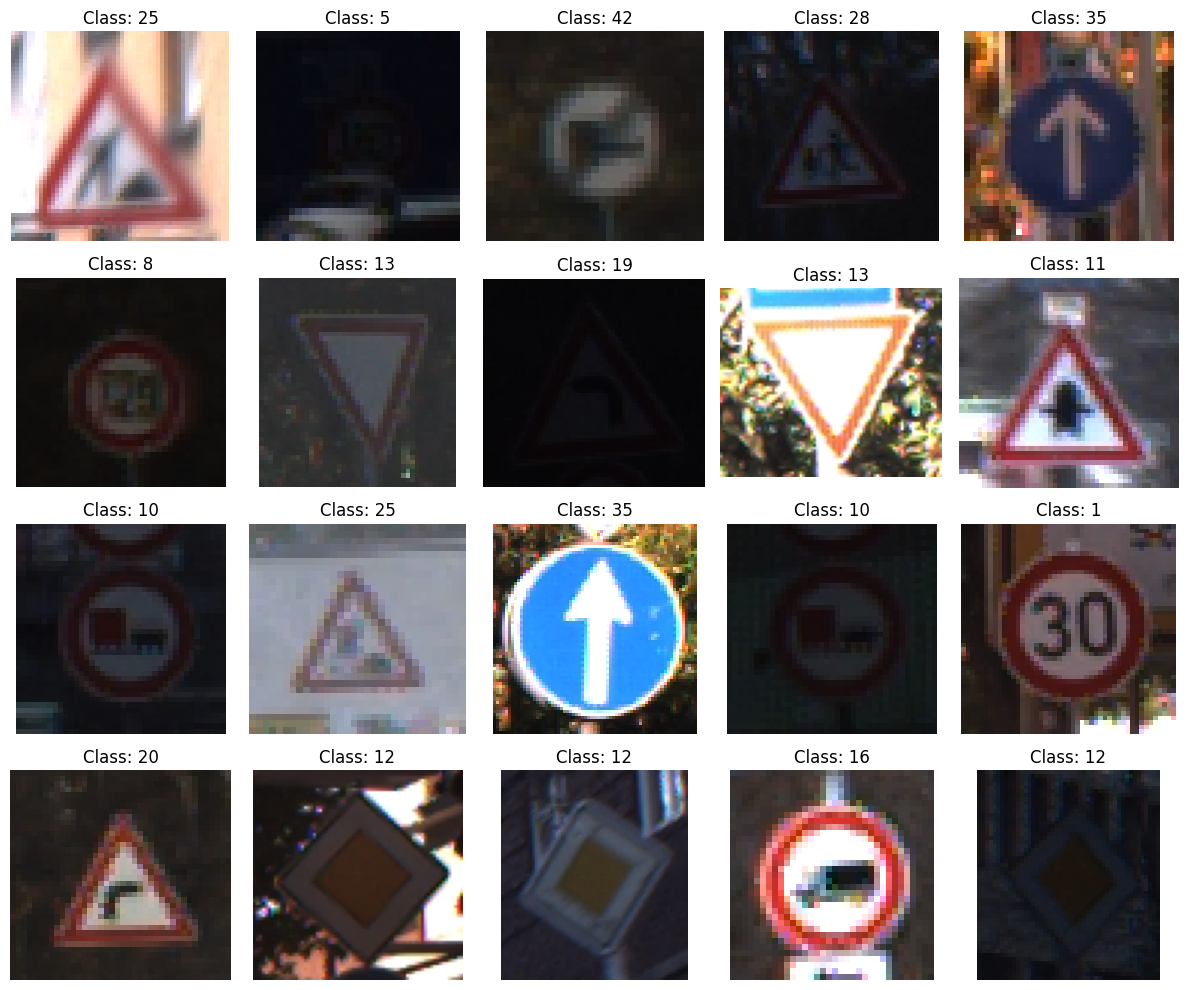

In [ ]:
#Visualize some random samples

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

axes = axes.flatten()

#Generate random indices
random_indices = np.random.choice(
    len(train_dataset),
    size=20,
    replace=False
)

for i in range(20):
    index = random_indices[i]
    image, label = train_dataset[index]

    axes[i].imshow(image)
    axes[i].set_title(f"Class: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Per verificare se il training set è bilanciato, viene conteggiato il numero di immagini appartenenti a ciascuna classe e la distribuzione ottenuta viene visualizzata tramite un grafico a barre.

Number of classes: 43
Samples per class: [ 150 1500 1500  960 1320 1260  300  960  960  990 1350  900 1410 1440
  540  420  300  750  810  150  240  240  270  360  180 1020  420  180
  360  180  300  540  180  480  300  810  270  150 1380  210  240  180
  180]


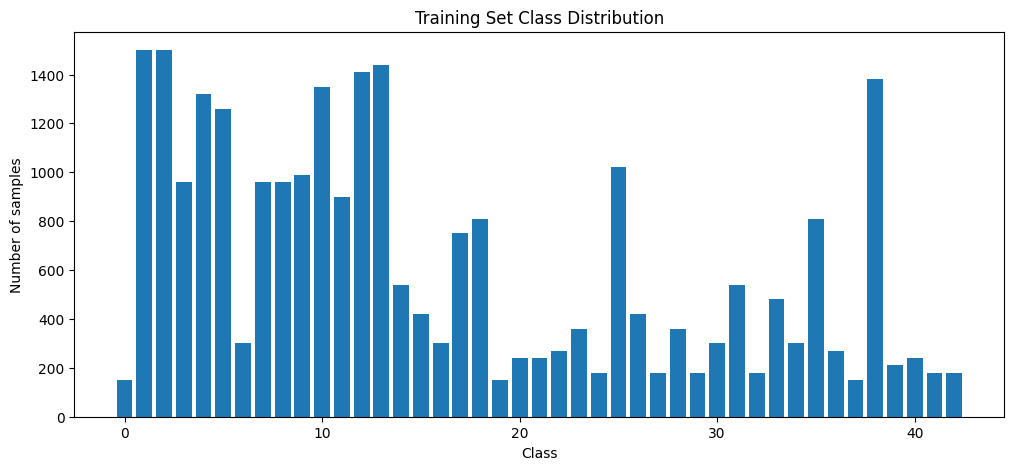

In [ ]:
# Collect the labels from the training set
labels = []

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    labels.append(label)

# Count the number of samples for each class
class_counts = np.bincount(labels)

print("Number of classes:", len(class_counts))
print("Samples per class:", class_counts)

# Plot the class distribution
classes = range(len(class_counts))

plt.figure(figsize=(12, 5))
plt.bar(classes, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Training Set Class Distribution")

plt.show()

Dal grafico si osserva che le classi non sono distribuite uniformemente: alcune contengono un numero di immagini sensibilmente maggiore rispetto ad altre. Per quantificare questo sbilanciamento, vengono quindi confrontati il numero minimo e massimo di campioni presenti nelle diverse classi.

In [ ]:
# Quantify class imbalance
print("Smallest class:", np.min(class_counts))
print("Largest class:", np.max(class_counts))

imbalance_ratio = np.max(class_counts) / np.min(class_counts)
print("Imbalance ratio:", imbalance_ratio)

Smallest class: 150
Largest class: 1500
Imbalance ratio: 10.0


I risultati confermano lo sbilanciamento osservato nel grafico: il numero di campioni per classe varia da 150 a 1500, con un rapporto di 10:1 tra la classe più rappresentata e quella meno rappresentata. Questa caratteristica dovrà essere tenuta in considerazione nelle successive fasi di addestramento e valutazione del modello.

Poiché le immagini del dataset possono avere dimensioni differenti, vengono analizzate separatamente larghezza e altezza. Per entrambe vengono calcolate alcune statistiche descrittive e visualizzata la relativa distribuzione.

First 10 image sizes:
[(29, 30), (30, 30), (30, 30), (31, 31), (30, 32), (31, 31), (33, 34), (34, 35), (33, 34), (36, 36)]


,Width,Height
count,26640.000000,26640.000000
mean,50.933784,50.365128
std,24.373418,23.161523
min,25.000000,25.000000
25%,35.000000,35.000000
50%,43.000000,43.000000
75%,58.000000,58.000000
max,243.000000,225.000000


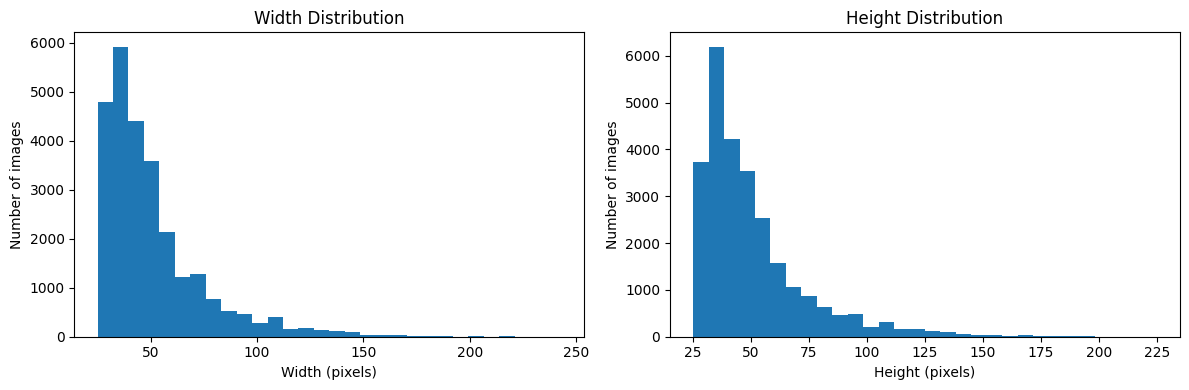

In [ ]:
#Analyze image dimensions
image_sizes = []

for i in range(len(train_dataset)):
    image, _ = train_dataset[i]
    image_sizes.append(image.size)

print("First 10 image sizes:")
print(image_sizes[:10])

#Create a dataframe with image dimensions
df_stats = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

#Summary statistics
display(df_stats.describe())

#Plot width and height distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_stats["Width"], bins=30)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Number of images")

axes[1].hist(df_stats["Height"], bins=30)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.show()

Le distribuzioni mostrano che la maggior parte delle immagini presenta dimensioni relativamente contenute, con larghezze e altezze concentrate soprattutto nei valori più bassi intorno a 50 pixel. Sono comunque presenti immagini di dimensioni sensibilmente maggiori, che determinano una distribuzione asimmetrica con una coda verso valori più elevati.

Oltre alle dimensioni assolute, è utile analizzare anche il rapporto tra larghezza e altezza delle immagini, cioè l’aspect ratio. Questo permette di capire se le immagini hanno proporzioni simili tra loro oppure se presentano forme molto diverse, informazione importante in vista del successivo ridimensionamento.

First 10 aspect ratios:
[0.9666666666666667, 1.0, 1.0, 1.0, 0.9375, 1.0, 0.9705882352941176, 0.9714285714285714, 0.9705882352941176, 1.0]


,Aspect Ratio
count,26640.000000
mean,1.008718
std,0.072100
min,0.368132
25%,0.972222
50%,1.000000
75%,1.044444
max,1.417808


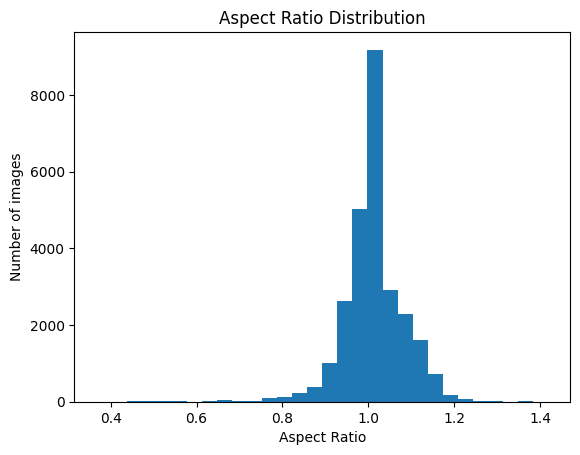

In [ ]:
#Analyze aspect ratio
df_stats["Aspect Ratio"] = df_stats["Width"] / df_stats["Height"]

print("First 10 aspect ratios:")
print(df_stats["Aspect Ratio"].head(10).tolist())

#Summary statistics
display(df_stats["Aspect Ratio"].describe())

#Plot the distribution
plt.hist(df_stats["Aspect Ratio"], bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Number of images")

plt.show()

La distribuzione dell’aspect ratio risulta concentrata principalmente intorno a 1, indicando che la maggior parte delle immagini presenta proporzioni vicine a quelle di un’immagine quadrata. Sebbene siano presenti alcuni campioni con proporzioni più estreme, un resize quadrato rappresenta quindi una scelta ragionevole per uniformare le dimensioni delle immagini prima di fornirle al modello.


---
### Exercise 1.2: A Stable and Reproducible Baseline
In questo esercizio viene costruita una baseline di riferimento utilizzando una rete pre-addestrata come feature extractor. Invece di utilizzare direttamente il classificatore finale della rete, vengono estratte per ogni immagine le feature prodotte dall’ultimo layer precedente alla classificazione. Queste rappresentazioni vengono quindi utilizzate per addestrare un classificatore tradizionale, in questo caso un SVM lineare. Infine, le prestazioni del modello vengono valutate sul test set, così da ottenere un risultato di riferimento con cui confrontare i successivi esperimenti di fine-tuning.

Come rete pre-addestrata viene utilizzata ResNet18, caricata con i pesi ottenuti dall’addestramento su ImageNet. In questa fase viene visualizzata la struttura del modello per identificare i diversi layer e, in particolare, il classificatore finale che verrà successivamente rimosso per utilizzare la rete come feature extractor.

In [ ]:
#Loading the pre-trained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights = weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Per utilizzare ResNet18 come feature extractor, il layer di classificazione finale fc viene sostituito con Identity(). In questo modo, l'output del modello non corrisponde più alle predizioni sulle classi di ImageNet, ma direttamente alla rappresentazione prodotta dal layer precedente al classificatore. Per ResNet18, questa rappresentazione è costituita da 512 feature per ogni immagine, che verranno successivamente utilizzate come input per il classificatore SVM.

In [ ]:
#Adapting ResNet18 as a feature extractor
model.fc = torch.nn.Identity()

Poiché ResNet18 è stata pre-addestrata utilizzando uno specifico preprocessing delle immagini, vengono recuperate direttamente dai pesi le trasformazioni raccomandate tramite weights.transforms(). Queste trasformazioni preparano le immagini nel formato atteso dal modello, occupandosi in particolare del ridimensionamento, della conversione in tensore e della normalizzazione. Viene quindi applicato il preprocessing a un'immagine di esempio per verificarne il tipo e le dimensioni risultanti.

In [ ]:
#Image preprocessing
processes = weights.transforms()

image,_ = train_dataset[0]
processed_image = processes(image)

print("Original type:", type(image))
print("Processed type:", type(processed_image))
print("Processed shape:", processed_image.shape)

Original type: <class 'PIL.Image.Image'>
Processed type: <class 'torch.Tensor'>
Processed shape: torch.Size([3, 224, 224])


Si osserva che dopo il preprocessing, l'immagine originale viene convertita in un tensore con forma [3, 224, 224], corrispondente ai tre canali RGB e alle dimensioni spaziali richieste dal modello

I dataset vengono adesso ricaricati applicando le trasformazioni direttamente al momento dell’accesso alle immagini. Vengono quindi creati i DataLoader, che permettono di elaborare il dataset in batch durante l’estrazione delle feature. Poiché in questa fase il modello non viene addestrato, non è necessario mescolare l’ordine dei campioni.

In [ ]:
#Dataset preprocessing and dataLoader creation
train_dataset = GTSRB(
    root="./data",
    split="train",
    download=True,
    transform=processes
)

test_dataset = GTSRB(
    root="./data",
    split="test",
    download=True,
    transform=processes
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = False #sto solo estraendo features, non allenamndo la rete, mi fa comodo cosi
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

In [ ]:
#Move the model to the selected device
model = model.to(device)
model.eval()

def extract_features(model, data_loader, device):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            features = model(images)

            all_features.append(features.cpu())
            all_labels.append(labels)

    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)

    return all_features, all_labels


# Extract features from train and test sets
train_features, train_labels = extract_features(
    model,
    train_loader,
    device
)

test_features, test_labels = extract_features(
    model,
    test_loader,
    device
)

print("Train features shape:", train_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: torch.Size([26640, 512])
Test features shape: torch.Size([12630, 512])


Le feature estratte da ResNet18 vengono convertite in array NumPy, formato richiesto da Scikit-learn, e utilizzate per addestrare un classificatore SVM lineare sul training set.

In [ ]:
#Training the Linear SVM Classifier
X_train = train_features.numpy()
y_train = train_labels.numpy()

X_test = test_features.numpy()
y_test = test_labels.numpy()


classifier = LinearSVC()
classifier.fit(X_train, y_train)

LinearSVC()

Una volta addestrato, il classificatore viene applicato alle feature del test set. Le predizioni ottenute vengono confrontate con le label reali utilizzando l'accuracy, così da quantificare le prestazioni della baseline su dati non utilizzati durante l'addestramento.

In [ ]:
#Evaluate the classifier on the test set
predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Test accuracy:", accuracy)

Test accuracy: 0.785193982581156


Il classificatore SVM addestrato sulle feature estratte dalla ResNet18 pre-addestrata raggiunge un’accuracy di circa 78.5% sul test set. Questo risultato costituisce una prima baseline per il task: nonostante la rete non sia stata adattata direttamente al dataset GTSRB, le rappresentazioni apprese durante il pre-training risultano già sufficientemente informative per ottenere buone prestazioni. Nei successivi esperimenti verrà verificato se il fine-tuning della rete permette di migliorare ulteriormente questo risultato.

Per analizzare più nel dettaglio le prestazioni del classificatore, viene visualizzata la confusion matrix, che permette di osservare la distribuzione delle predizioni corrette e individuare eventuali classi che vengono confuse più frequentemente.

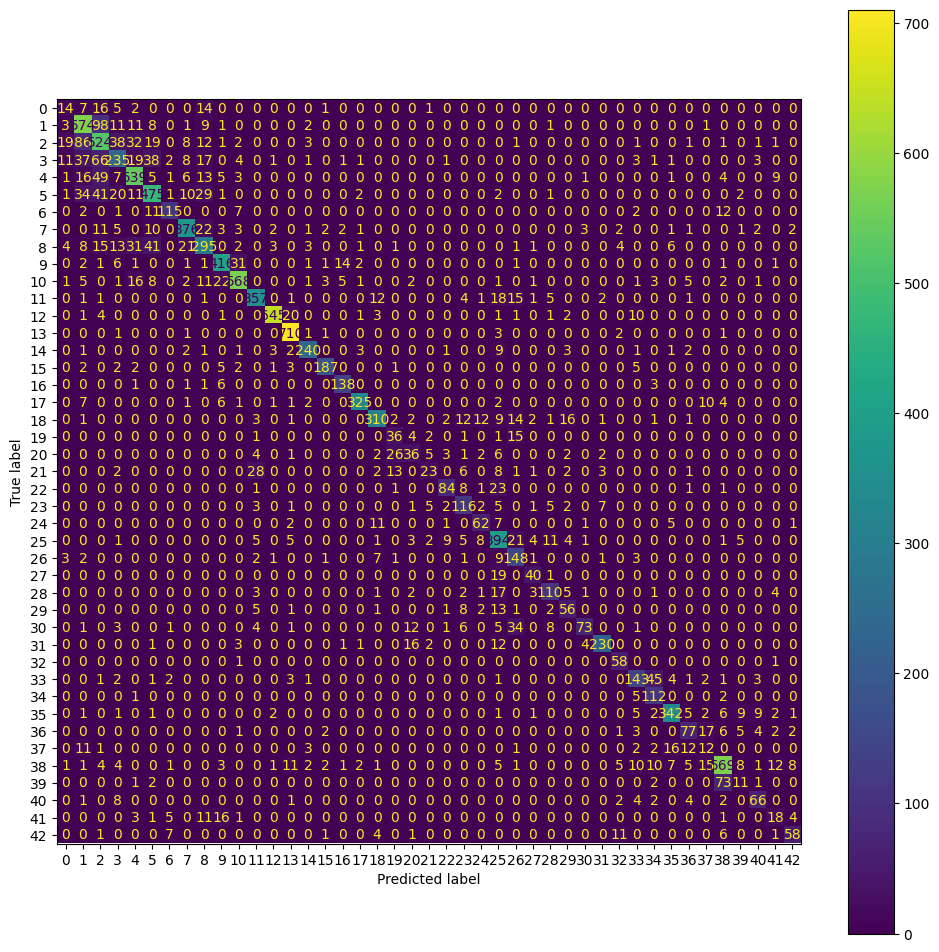

In [ ]:
#Compute and display the confusion matrix
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax)

plt.show()

La confusion matrix mostra una chiara concentrazione dei valori lungo la diagonale principale, indicando che la maggior parte dei campioni viene classificata correttamente. Sono comunque presenti alcuni errori tra classi differenti, più evidenti per alcune categorie. Nel complesso, il risultato conferma che le feature estratte dalla ResNet18 pre-addestrata forniscono una rappresentazione efficace delle immagini anche senza effettuare il fine-tuning della rete.


---
### Exercise 1.3: A Fine-tuning Baseline
In questo esercizio la ResNet18 pre-addestrata viene adattata direttamente al task di classificazione del dataset GTSRB tramite fine-tuning. A differenza della baseline precedente, in cui la rete veniva utilizzata esclusivamente come feature extractor e la classificazione era affidata a un modello esterno, in questo caso viene sostituito il classificatore finale della rete e parte dei pesi del modello viene aggiornata durante l'addestramento.

Per limitare il costo computazionale e preservare le rappresentazioni generali apprese durante il pre-training, vengono mantenuti congelati i primi layer della rete e vengono addestrati solamente gli ultimi due blocchi insieme al nuovo classificatore. Il training set viene inoltre suddiviso in training e validation set, utilizzando quest'ultimo per monitorare la capacità di generalizzazione del modello e individuare eventuali fenomeni di overfitting. L'addestramento viene eseguito per un numero massimo di epoche, introducendo un criterio di early stopping basato sulla validation loss.

In [ ]:
#Create training and validation subsets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))

#Create DataLoaders

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Training samples: 21312
Validation samples: 5328


In [ ]:
#Fine-Tuning model configuration

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

model.fc = torch.nn.Linear(512, 43)

#Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

#Fine-tune the last two residual blocks
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

#Train the new classifier
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Per il task di classificazione multiclasse viene utilizzata la CrossEntropyLoss. L’ottimizzatore Adam aggiorna esclusivamente i parametri resi addestrabili, utilizzando un learning rate ridotto per evitare modifiche troppo aggressive ai pesi pre-addestrati.

In [ ]:
#Loss function
criterion = torch.nn.CrossEntropyLoss()

#Optimize only trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

Il modello viene addestrato per un massimo di 10 epoche, monitorando sia la training loss sia la validation loss. Per limitare l’overfitting viene utilizzato un criterio di early stopping con patience=3: se la validation loss non migliora per tre epoche consecutive, l’addestramento viene interrotto. Durante il training viene inoltre conservato il checkpoint corrispondente alla minima validation loss.

In [ ]:
#Fine-tuning

num_epochs = 10
patience = 3

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
counter = 0

for epoch in range(num_epochs):

    #Training
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    #Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train loss: {train_loss:.4f} - "
        f"Val loss: {val_loss:.4f} - "
        f"Val accuracy: {val_accuracy:.4f}"
    )

    #Check validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

#Restore the best model
model.load_state_dict(best_model_state)
model = model.to(device)

Epoch 1/15 - Train loss: 0.3689 - Val loss: 0.0321 - Val accuracy: 0.9938
Epoch 2/15 - Train loss: 0.0147 - Val loss: 0.0143 - Val accuracy: 0.9964
Epoch 3/15 - Train loss: 0.0096 - Val loss: 0.0068 - Val accuracy: 0.9976
Epoch 4/15 - Train loss: 0.0065 - Val loss: 0.0076 - Val accuracy: 0.9981
Epoch 5/15 - Train loss: 0.0072 - Val loss: 0.0069 - Val accuracy: 0.9981
Epoch 6/15 - Train loss: 0.0027 - Val loss: 0.0063 - Val accuracy: 0.9987
Epoch 7/15 - Train loss: 0.0092 - Val loss: 0.0108 - Val accuracy: 0.9972
Epoch 8/15 - Train loss: 0.0068 - Val loss: 0.0050 - Val accuracy: 0.9989
Epoch 9/15 - Train loss: 0.0051 - Val loss: 0.0730 - Val accuracy: 0.9839
Epoch 10/15 - Train loss: 0.0028 - Val loss: 0.0018 - Val accuracy: 0.9998
Epoch 11/15 - Train loss: 0.0002 - Val loss: 0.0012 - Val accuracy: 0.9996
Epoch 12/15 - Train loss: 0.0007 - Val loss: 0.0212 - Val accuracy: 0.9942
Epoch 13/15 - Train loss: 0.0098 - Val loss: 0.0088 - Val accuracy: 0.9976
Epoch 14/15 - Train loss: 0.0019 -

Dopo aver ripristinato il checkpoint con la validation loss minima, il modello viene valutato sul test set, utilizzato esclusivamente per stimare le prestazioni finali su dati non osservati durante training e selezione del modello.

In [22]:
# Evaluate the final model
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9870942201108472



---
## Exercise 2: Pipeline Consolidation
Nell’esercizio precedente il processo di fine-tuning è stato implementato direttamente attraverso diverse celle del notebook. In questo esercizio il codice viene quindi riorganizzato in una pipeline più generale e riproducibile, in modo da poter eseguire facilmente nuovi esperimenti modificando soltanto alcuni parametri di configurazione.

In particolare, le principali impostazioni dell’addestramento, come learning rate, batch size, numero massimo di epoche, optimizer e strategia di fine-tuning, vengono raccolte in una configurazione unica. Le procedure di training e validation vengono inoltre racchiuse in funzioni riutilizzabili, permettendo di confrontare diverse configurazioni senza dover riscrivere l’intero codice.

In [23]:
#Experiment configuration

config = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "num_epochs": 6,
    "patience": 3,
    "train_layer3": True,
    "train_layer4": True,
    "optimizer": "adam",
    "seed": 42
}

In [24]:
#Create the model

def create_model(config):

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    # Replace the original classifier
    model.fc = torch.nn.Linear(512, 43)

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Selectively unfreeze the last residual blocks
    if config["train_layer3"]:
        for param in model.layer3.parameters():
            param.requires_grad = True

    if config["train_layer4"]:
        for param in model.layer4.parameters():
            param.requires_grad = True

    # Always train the new classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [25]:
#Create loss function and optimizer

def create_training_components(model, config):

    criterion = torch.nn.CrossEntropyLoss()

    trainable_params = filter(
        lambda p: p.requires_grad,
        model.parameters()
    )

    if config["optimizer"] == "adam":

        optimizer = torch.optim.Adam(
            trainable_params,
            lr=config["learning_rate"]
        )

    elif config["optimizer"] == "sgd":

        optimizer = torch.optim.SGD(
            trainable_params,
            lr=config["learning_rate"]
        )

    else:
        raise ValueError("Unsupported optimizer")

    return criterion, optimizer

In [26]:
#Create datasets

def create_datasets():

    weights = ResNet18_Weights.DEFAULT
    transform = weights.transforms()

    train_dataset = GTSRB(
        root="./data",
        split="train",
        download=True,
        transform=transform
    )

    test_dataset = GTSRB(
        root="./data",
        split="test",
        download=True,
        transform=transform
    )

    return train_dataset, test_dataset

In [27]:
#Create DataLoaders

def create_dataloaders(train_dataset, test_dataset, config):

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    # Reproducible train-validation split
    generator = torch.Generator().manual_seed(config["seed"])

    train_subset, val_subset = random_split(
        train_dataset,
        [train_size, val_size],
        generator=generator
    )

    train_loader = DataLoader(
        train_subset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [28]:
#Train the model

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    config,
    device
):

    train_losses = []
    val_losses = []

    num_epochs = config["num_epochs"]
    patience = config["patience"]

    best_val_loss = float("inf")
    best_model_state = None
    counter = 0

    model = model.to(device)

    for epoch in range(num_epochs):

        # Training
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_epoch_loss = running_loss / len(train_loader)
        train_losses.append(train_epoch_loss)

        # Validation
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_epoch_loss = val_running_loss / len(val_loader)
        val_accuracy = correct / total

        val_losses.append(val_epoch_loss)

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train loss: {train_epoch_loss:.4f} - "
            f"Val loss: {val_epoch_loss:.4f} - "
            f"Val accuracy: {val_accuracy:.4f}"
        )

        # Save the best model according to validation loss
        if val_epoch_loss < best_val_loss:

            best_val_loss = val_epoch_loss

            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

            counter = 0

        else:
            counter += 1

        # Early stopping
        if counter >= patience:
            print("Early stopping")
            break

    # Restore the best model
    model.load_state_dict(best_model_state)
    model = model.to(device)

    return train_losses, val_losses

In [29]:
#Evaluate the model

def evaluate_model(model, test_loader, device):

    model = model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    test_accuracy = correct / total

    return test_accuracy

In [ ]:
#Run the experiment

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

train_dataset, test_dataset = create_datasets()

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset,
    test_dataset,
    config
)

model = create_model(config)

criterion, optimizer = create_training_components(
    model,
    config
)

train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    config,
    device
)

test_accuracy = evaluate_model(
    model,
    test_loader,
    device
)

print("Test accuracy:", test_accuracy)


---
## Exercise 3: Choose your Own Adventure



---
### Exercise 3.1: Improving Fine-tuning Performance

Partendo dalla configurazione di fine-tuning utilizzata in precedenza, che mostra già prestazioni eccellenti con un'accuracy sul Test Set pari al 98.71%, in questo esercizio si introducono progressivamente alcune modifiche. L'obiettivo è verificare se sia possibile ottimizzare ulteriormente il modello. Ogni intervento viene motivato sulla base delle caratteristiche del dataset e dei risultati osservati negli esperimenti precedenti, mantenendo invariati gli altri elementi della pipeline quando possibile.

Il primo intervento riguarda lo sbilanciamento tra le classi osservato durante l’analisi esplorativa del dataset. Poiché alcune classi contengono molti più campioni di altre, una normale CrossEntropyLoss tende a dare maggiore peso alle classi più rappresentate. Per compensare questo effetto, vengono quindi introdotti pesi inversamente proporzionali alla frequenza delle classi, assegnando maggiore importanza agli errori commessi sulle classi meno rappresentate.

In [ ]:
# Experiment 1: Class-weighted loss

#Compute class weights
labels = []

for _, label in train_dataset:
    labels.append(label)

class_counts = np.bincount(labels)

class_weights = len(labels) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


#Create a new model
model_weighted = create_model(config)

#Define the weighted loss
criterion_weighted = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

#Create the optimizer using the existing function
_, optimizer_weighted = create_training_components(
    model_weighted,
    config
)

#Train
train_losses_weighted, val_losses_weighted = train_model(
    model_weighted,
    train_loader,
    val_loader,
    criterion_weighted,
    optimizer_weighted,
    config,
    device
)

#Evaluate
test_accuracy_weighted = evaluate_model(
    model_weighted,
    test_loader,
    device
)

print("Weighted loss test accuracy:", test_accuracy_weighted)

Epoch 1/6 - Train loss: 0.4736 - Val loss: 0.0285 - Val accuracy: 0.9931
Epoch 2/6 - Train loss: 0.0167 - Val loss: 0.0158 - Val accuracy: 0.9923


Nel secondo esperimento viene mantenuta la loss pesata introdotta in precedenza e viene aggiunta una data augmentation leggera al training set. L’obiettivo è aumentare la variabilità dei dati osservati durante l’addestramento e migliorare la capacità di generalizzazione del modello, senza alterare in modo eccessivo la struttura dei segnali stradali.

In [ ]:
# Experiment 2: Weighted loss + data augmentation

#Training transformations with light augmentation
train_transform_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(10),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Standard preprocessing for validation/test
eval_transform = weights.transforms()

#Create augmented training dataset
train_dataset_aug = GTSRB(
    root="./data",
    split="train",
    download=True,
    transform=train_transform_aug
)

#Reproduce the same train/validation split
generator = torch.Generator().manual_seed(config["seed"])

train_size = int(0.8 * len(train_dataset_aug))
val_size = len(train_dataset_aug) - train_size

train_subset_aug, _ = random_split(
    train_dataset_aug,
    [train_size, val_size],
    generator=generator
)

#Validation subset with standard preprocessing
train_dataset_eval = GTSRB(
    root="./data",
    split="train",
    download=True,
    transform=eval_transform
)

generator = torch.Generator().manual_seed(config["seed"])

_, val_subset_aug = random_split(
    train_dataset_eval,
    [train_size, val_size],
    generator=generator
)

train_loader_aug = DataLoader(
    train_subset_aug,
    batch_size=config["batch_size"],
    shuffle=True
)

val_loader_aug = DataLoader(
    val_subset_aug,
    batch_size=config["batch_size"],
    shuffle=False
)

#Create a fresh model
model_aug = create_model(config)

#Reuse weighted loss
criterion_aug = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

#Optimizer
_, optimizer_aug = create_training_components(
    model_aug,
    config
)

#Train
train_losses_aug, val_losses_aug = train_model(
    model_aug,
    train_loader_aug,
    val_loader_aug,
    criterion_aug,
    optimizer_aug,
    config,
    device
)

#Evaluate on the same test set
test_accuracy_aug = evaluate_model(
    model_aug,
    test_loader,
    device
)

print("Weighted loss + augmentation test accuracy:", test_accuracy_aug)

Nell’ultimo esperimento viene modificato il preprocessing sulla base delle dimensioni osservate durante l’analisi esplorativa. Poiché la maggior parte delle immagini presenta una risoluzione dell’ordine di circa 50×50 pixel e un aspect ratio vicino a 1, viene testato un resize quadrato a 50×50, mantenendo la weighted loss e la data augmentation introdotte negli esperimenti precedenti.

In [ ]:
# Experiment 3: Weighted loss + data augmentation + custom resize

#Training transformation
custom_train_transform = T.Compose([
    T.Resize((50, 50)),
    T.RandomRotation(10),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Validation and test transformation
custom_eval_transform = T.Compose([
    T.Resize((50, 50)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Create datasets
train_dataset_custom = GTSRB(
    root="./data",
    split="train",
    download=True,
    transform=custom_train_transform
)

train_dataset_custom_eval = GTSRB(
    root="./data",
    split="train",
    download=True,
    transform=custom_eval_transform
)

test_dataset_custom = GTSRB(
    root="./data",
    split="test",
    download=True,
    transform=custom_eval_transform
)

#Reproduce the same train/validation split
train_size = int(0.8 * len(train_dataset_custom))
val_size = len(train_dataset_custom) - train_size

generator = torch.Generator().manual_seed(config["seed"])

train_subset_custom, _ = random_split(
    train_dataset_custom,
    [train_size, val_size],
    generator=generator
)

generator = torch.Generator().manual_seed(config["seed"])

_, val_subset_custom = random_split(
    train_dataset_custom_eval,
    [train_size, val_size],
    generator=generator
)

#Create DataLoaders
train_loader_custom = DataLoader(
    train_subset_custom,
    batch_size=config["batch_size"],
    shuffle=True
)

val_loader_custom = DataLoader(
    val_subset_custom,
    batch_size=config["batch_size"],
    shuffle=False
)

test_loader_custom = DataLoader(
    test_dataset_custom,
    batch_size=config["batch_size"],
    shuffle=False
)

#Create a fresh model
model_custom = create_model(config)

#Weighted loss
criterion_custom = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

#Optimizer
_, optimizer_custom = create_training_components(
    model_custom,
    config
)

#Train
train_losses_custom, val_losses_custom = train_model(
    model_custom,
    train_loader_custom,
    val_loader_custom,
    criterion_custom,
    optimizer_custom,
    config,
    device
)

#Evaluate
test_accuracy_custom = evaluate_model(
    model_custom,
    test_loader_custom,
    device
)

print("Custom preprocessing test accuracy:", test_accuracy_custom)